In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from scipy.linalg import svd as scipy_svd

In [8]:
print("PERSON 3: ORTHOGONALIZATION & PROJECTION")


PERSON 3: ORTHOGONALIZATION & PROJECTION


In [11]:
# ============================================
# LOAD DATA FROM PERSON 2
# ============================================

# Load the pickle file
with open('../output/person2_data.pkl', 'rb') as f:
    person2_data = pickle.load(f)

# Extract all necessary data
images = person2_data['images']
hero_image = person2_data['hero_image']
hero_name = person2_data['hero_name']
labels = person2_data['labels']
filenames = person2_data['filenames']
hero_idx = person2_data['hero_idx']

# SVD components from Person 2
U = person2_data['hero_U']
sigma = person2_data['hero_sigma']
Vt = person2_data['hero_Vt']

# Space analysis from Person 2
rank = person2_data['rank']
nullity = person2_data['nullity']
k_optimal = person2_data['k_optimal']


print("\n✓ Data loaded successfully!")
print(f"\n--- Loaded Data Summary ---")
print(f"Total images: {len(images)}")
print(f"Hero image: {hero_name}")
print(f"Hero image shape: {hero_image.shape}")
print(f"\nSVD Components:")
print(f"  U shape: {U.shape}")
print(f"  Sigma shape: {sigma.shape}")
print(f"  Vt shape: {Vt.shape}")
print(f"\nFrom Person 2's analysis:")
print(f"  Rank: {rank}")
print(f"  Nullity: {nullity}")
print(f"  Optimal k: {k_optimal}")



✓ Data loaded successfully!

--- Loaded Data Summary ---
Total images: 18
Hero image: Chest_2.png
Hero image shape: (512, 512)

SVD Components:
  U shape: (512, 512)
  Sigma shape: (512,)
  Vt shape: (512, 512)

From Person 2's analysis:
  Rank: 492
  Nullity: 20
  Optimal k: 50


In [12]:
# ============================================
# STEP 6: ORTHOGONALIZATION
# Part 1: Verify U is Orthogonal
# ============================================

print("\n" + "="*60)
print("STEP 6: ORTHOGONALIZATION")
print("="*60)

print("\n--- Theoretical Background ---")
print("In SVD decomposition A = UΣV^T:")
print("  • U is an orthogonal matrix (columns are orthonormal)")
print("  • V is an orthogonal matrix (columns are orthonormal)")
print("  • Orthonormal means: unit length AND perpendicular to each other")
print("\nProperty to verify: U^T U = I (Identity matrix)")

print("\n" + "-"*60)
print("VERIFYING U IS ORTHOGONAL")
print("-"*60)

# Compute U^T U
UtU = U.T @ U

# Check if it equals identity matrix
is_identity_U = np.allclose(UtU, np.eye(U.shape[1]), atol=1e-10)

print(f"\nU matrix shape: {U.shape}")
print(f"U^T U shape: {UtU.shape}")
print(f"Expected: Identity matrix I_{{{U.shape[1]}×{U.shape[1]}}}")
print(f"\n✓ Is U^T U = I? {is_identity_U}")

# Analyze diagonal elements (should be 1)
diagonal_U = np.diag(UtU)
print(f"\n--- Diagonal Elements Analysis ---")
print(f"Expected value: 1.0 (unit length vectors)")
print(f"Mean: {diagonal_U.mean():.15f}")
print(f"Std deviation: {diagonal_U.std():.2e}")
print(f"Min: {diagonal_U.min():.15f}")
print(f"Max: {diagonal_U.max():.15f}")
print(f"Deviation from 1.0: {np.abs(diagonal_U - 1.0).max():.2e}")

# Analyze off-diagonal elements (should be 0)
off_diagonal_U = UtU - np.diag(diagonal_U)
print(f"\n--- Off-Diagonal Elements Analysis ---")
print(f"Expected value: 0.0 (perpendicular vectors)")
print(f"Max absolute value: {np.abs(off_diagonal_U).max():.2e}")
print(f"Mean absolute value: {np.abs(off_diagonal_U).mean():.2e}")

# Verify individual column norms
print(f"\n--- Unit Length Verification (First 10 columns) ---")
for i in range(min(10, U.shape[1])):
    col_norm = np.linalg.norm(U[:, i])
    print(f"||U[:, {i:2d}]|| = {col_norm:.15f}")

# Verify orthogonality between column pairs
print(f"\n--- Perpendicularity Verification (Sample pairs) ---")
for i in range(min(5, U.shape[1])):
    for j in range(i+1, min(i+3, U.shape[1])):
        dot_product = np.dot(U[:, i], U[:, j])
        print(f"U[:, {i}] · U[:, {j}] = {dot_product:.2e}")

print("\n✓ U orthogonality verification complete!")


STEP 6: ORTHOGONALIZATION

--- Theoretical Background ---
In SVD decomposition A = UΣV^T:
  • U is an orthogonal matrix (columns are orthonormal)
  • V is an orthogonal matrix (columns are orthonormal)
  • Orthonormal means: unit length AND perpendicular to each other

Property to verify: U^T U = I (Identity matrix)

------------------------------------------------------------
VERIFYING U IS ORTHOGONAL
------------------------------------------------------------

U matrix shape: (512, 512)
U^T U shape: (512, 512)
Expected: Identity matrix I_{512×512}

✓ Is U^T U = I? True

--- Diagonal Elements Analysis ---
Expected value: 1.0 (unit length vectors)
Mean: 1.000000000000000
Std deviation: 5.46e-16
Min: 0.999999999999998
Max: 1.000000000000002
Deviation from 1.0: 2.11e-15

--- Off-Diagonal Elements Analysis ---
Expected value: 0.0 (perpendicular vectors)
Max absolute value: 2.70e-15
Mean absolute value: 6.03e-17

--- Unit Length Verification (First 10 columns) ---
||U[:,  0]|| = 1.000000

In [13]:
# ============================================
# STEP 6: ORTHOGONALIZATION
# Part 2: Verify V is Orthogonal
# ============================================

print("\n" + "-"*60)
print("VERIFYING V IS ORTHOGONAL")
print("-"*60)

# Get V from V^T (since SVD returns V^T)
V = Vt.T

# Compute V^T V
VtV = Vt @ V

# Check if it equals identity
is_identity_V = np.allclose(VtV, np.eye(V.shape[1]), atol=1e-10)

print(f"\nV matrix shape: {V.shape}")
print(f"V^T (from SVD): {Vt.shape}")
print(f"V^T V shape: {VtV.shape}")
print(f"\n✓ Is V^T V = I? {is_identity_V}")

# Analyze diagonal elements
diagonal_V = np.diag(VtV)
print(f"\n--- Diagonal Elements Analysis ---")
print(f"Expected value: 1.0")
print(f"Mean: {diagonal_V.mean():.15f}")
print(f"Std deviation: {diagonal_V.std():.2e}")
print(f"Min: {diagonal_V.min():.15f}")
print(f"Max: {diagonal_V.max():.15f}")

# Analyze off-diagonal elements
off_diagonal_V = VtV - np.diag(diagonal_V)
print(f"\n--- Off-Diagonal Elements Analysis ---")
print(f"Expected value: 0.0")
print(f"Max absolute value: {np.abs(off_diagonal_V).max():.2e}")
print(f"Mean absolute value: {np.abs(off_diagonal_V).mean():.2e}")

# Verify individual column norms
print(f"\n--- Unit Length Verification (First 10 columns) ---")
for i in range(min(10, V.shape[1])):
    col_norm = np.linalg.norm(V[:, i])
    print(f"||V[:, {i:2d}]|| = {col_norm:.15f}")

print("\n✓ V orthogonality verification complete!")


------------------------------------------------------------
VERIFYING V IS ORTHOGONAL
------------------------------------------------------------

V matrix shape: (512, 512)
V^T (from SVD): (512, 512)
V^T V shape: (512, 512)

✓ Is V^T V = I? True

--- Diagonal Elements Analysis ---
Expected value: 1.0
Mean: 1.000000000000000
Std deviation: 6.09e-16
Min: 0.999999999999998
Max: 1.000000000000002

--- Off-Diagonal Elements Analysis ---
Expected value: 0.0
Max absolute value: 2.51e-15
Mean absolute value: 6.01e-17

--- Unit Length Verification (First 10 columns) ---
||V[:,  0]|| = 1.000000000000000
||V[:,  1]|| = 1.000000000000000
||V[:,  2]|| = 1.000000000000001
||V[:,  3]|| = 1.000000000000000
||V[:,  4]|| = 1.000000000000000
||V[:,  5]|| = 1.000000000000000
||V[:,  6]|| = 1.000000000000001
||V[:,  7]|| = 1.000000000000000
||V[:,  8]|| = 1.000000000000000
||V[:,  9]|| = 1.000000000000000

✓ V orthogonality verification complete!


In [15]:
# ============================================
# ORTHOGONALIZATION SUMMARY
# ============================================

print("\n" + "="*60)
print("ORTHOGONALIZATION SUMMARY")
print("="*60)

print("\n✅ VERIFICATION RESULTS:")
print(f"  U is orthogonal: {is_identity_U} ✓")
print(f"  V is orthogonal: {is_identity_V} ✓")

print("\n ORTHONORMAL BASIS PROPERTIES CONFIRMED:")
print("  1. Unit Length: ||u_i|| = 1 for all columns")
print("  2. Perpendicularity: u_i · u_j = 0 for i ≠ j")
print("  3. U^T U = I and V^T V = I")

print("\n WHAT THIS MEANS FOR COMPRESSION:")
print(f"  • {U.shape[1]} orthonormal vectors in U span the column space")
print(f"  • {V.shape[1]} orthonormal vectors in V span the row space")
print("  • These form the OPTIMAL basis for compression")
print("  • Orthogonality ensures no redundancy in our basis")

print("\n CONNECTION TO GRAM-SCHMIDT:")
print("  • SVD automatically produces orthonormal bases")
print("  • No need to manually apply Gram-Schmidt process")
print("  • This is one of SVD's key advantages!")


ORTHOGONALIZATION SUMMARY

✅ VERIFICATION RESULTS:
  U is orthogonal: True ✓
  V is orthogonal: True ✓

 ORTHONORMAL BASIS PROPERTIES CONFIRMED:
  1. Unit Length: ||u_i|| = 1 for all columns
  2. Perpendicularity: u_i · u_j = 0 for i ≠ j
  3. U^T U = I and V^T V = I

 WHAT THIS MEANS FOR COMPRESSION:
  • 512 orthonormal vectors in U span the column space
  • 512 orthonormal vectors in V span the row space
  • These form the OPTIMAL basis for compression
  • Orthogonality ensures no redundancy in our basis

 CONNECTION TO GRAM-SCHMIDT:
  • SVD automatically produces orthonormal bases
  • No need to manually apply Gram-Schmidt process
  • This is one of SVD's key advantages!



📊 Creating orthogonality visualizations...


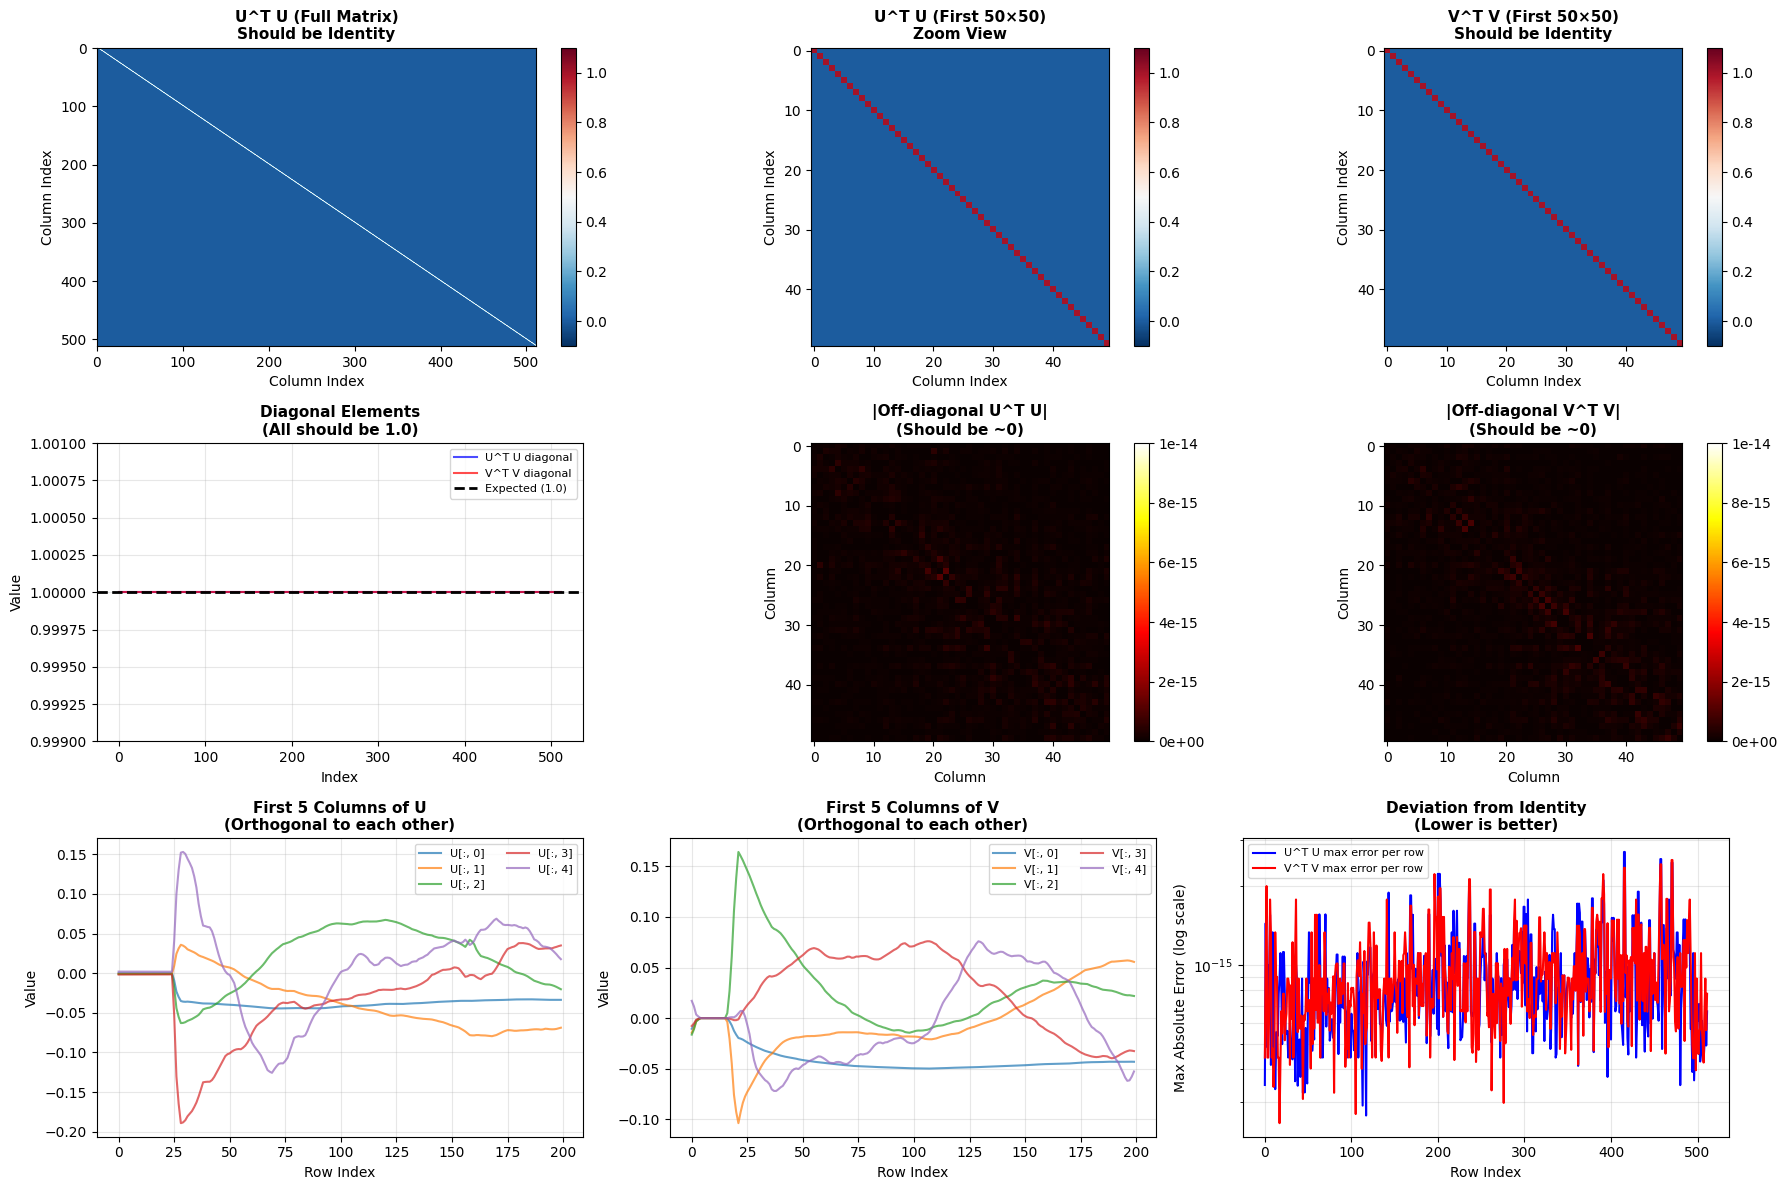

✓ Orthogonality visualization saved to: output/person3/orthogonality_verification.png


In [16]:
# ============================================
# VISUALIZE ORTHOGONALITY
# ============================================

print("\n📊 Creating orthogonality visualizations...")

fig = plt.figure(figsize=(18, 12))

# --- U^T U Heatmap (Full) ---
ax1 = plt.subplot(3, 3, 1)
im1 = ax1.imshow(UtU, cmap='RdBu_r', vmin=-0.1, vmax=1.1, aspect='auto')
ax1.set_title('U^T U (Full Matrix)\nShould be Identity', fontsize=11, fontweight='bold')
ax1.set_xlabel('Column Index')
ax1.set_ylabel('Column Index')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# --- U^T U Heatmap (First 50×50) ---
ax2 = plt.subplot(3, 3, 2)
im2 = ax2.imshow(UtU[:50, :50], cmap='RdBu_r', vmin=-0.1, vmax=1.1)
ax2.set_title('U^T U (First 50×50)\nZoom View', fontsize=11, fontweight='bold')
ax2.set_xlabel('Column Index')
ax2.set_ylabel('Column Index')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# --- V^T V Heatmap ---
ax3 = plt.subplot(3, 3, 3)
im3 = ax3.imshow(VtV[:50, :50], cmap='RdBu_r', vmin=-0.1, vmax=1.1)
ax3.set_title('V^T V (First 50×50)\nShould be Identity', fontsize=11, fontweight='bold')
ax3.set_xlabel('Column Index')
ax3.set_ylabel('Column Index')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# --- Diagonal Elements ---
ax4 = plt.subplot(3, 3, 4)
ax4.plot(diagonal_U, 'b-', label='U^T U diagonal', linewidth=1.5, alpha=0.7)
ax4.plot(diagonal_V, 'r-', label='V^T V diagonal', linewidth=1.5, alpha=0.7)
ax4.axhline(y=1.0, color='k', linestyle='--', linewidth=2, label='Expected (1.0)')
ax4.set_xlabel('Index', fontsize=10)
ax4.set_ylabel('Value', fontsize=10)
ax4.set_title('Diagonal Elements\n(All should be 1.0)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0.999, 1.001])

# --- Off-Diagonal Magnitude (U) ---
ax5 = plt.subplot(3, 3, 5)
off_diag_abs_U = np.abs(off_diagonal_U)
im5 = ax5.imshow(off_diag_abs_U[:50, :50], cmap='hot', vmin=0, vmax=1e-14)
ax5.set_title('|Off-diagonal U^T U|\n(Should be ~0)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Column')
ax5.set_ylabel('Column')
plt.colorbar(im5, ax=ax5, fraction=0.046, format='%.0e')

# --- Off-Diagonal Magnitude (V) ---
ax6 = plt.subplot(3, 3, 6)
off_diag_abs_V = np.abs(off_diagonal_V)
im6 = ax6.imshow(off_diag_abs_V[:50, :50], cmap='hot', vmin=0, vmax=1e-14)
ax6.set_title('|Off-diagonal V^T V|\n(Should be ~0)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Column')
ax6.set_ylabel('Column')
plt.colorbar(im6, ax=ax6, fraction=0.046, format='%.0e')

# --- First 5 U columns ---
ax7 = plt.subplot(3, 3, 7)
for i in range(5):
    ax7.plot(U[:200, i], label=f'U[:, {i}]', alpha=0.7, linewidth=1.5)
ax7.set_xlabel('Row Index', fontsize=10)
ax7.set_ylabel('Value', fontsize=10)
ax7.set_title('First 5 Columns of U\n(Orthogonal to each other)', fontsize=11, fontweight='bold')
ax7.legend(fontsize=8, ncol=2)
ax7.grid(True, alpha=0.3)

# --- First 5 V columns ---
ax8 = plt.subplot(3, 3, 8)
for i in range(5):
    ax8.plot(V[:200, i], label=f'V[:, {i}]', alpha=0.7, linewidth=1.5)
ax8.set_xlabel('Row Index', fontsize=10)
ax8.set_ylabel('Value', fontsize=10)
ax8.set_title('First 5 Columns of V\n(Orthogonal to each other)', fontsize=11, fontweight='bold')
ax8.legend(fontsize=8, ncol=2)
ax8.grid(True, alpha=0.3)

# --- Error from Identity ---
ax9 = plt.subplot(3, 3, 9)
error_U = np.abs(UtU - np.eye(UtU.shape[0]))
error_V = np.abs(VtV - np.eye(VtV.shape[0]))
max_errors_U = error_U.max(axis=1)
max_errors_V = error_V.max(axis=1)
ax9.semilogy(max_errors_U, 'b-', label='U^T U max error per row', linewidth=1.5)
ax9.semilogy(max_errors_V, 'r-', label='V^T V max error per row', linewidth=1.5)
ax9.set_xlabel('Row Index', fontsize=10)
ax9.set_ylabel('Max Absolute Error (log scale)', fontsize=10)
ax9.set_title('Deviation from Identity\n(Lower is better)', fontsize=11, fontweight='bold')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3, which='both')

plt.tight_layout()

# Save
os.makedirs('../output/person3', exist_ok=True)
plt.savefig('../output/person3/orthogonality_verification.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Orthogonality visualization saved to: output/person3/orthogonality_verification.png")

In [17]:
# ============================================
# STEP 7: PROJECTION ONTO SUBSPACES
# Part 1: Theory and Setup
# ============================================

print("\n" + "="*60)
print("STEP 7: PROJECTION ONTO SUBSPACES")
print("="*60)

print("\n--- PROJECTION THEORY ---")
print("\n Goal: Project high-dimensional image onto lower-dimensional subspace")
print(f"   Original space: ℝ^{hero_image.shape[1]} ({hero_image.shape[1]}-dimensional)")
print(f"   Target subspace: ℝ^{k_optimal} ({k_optimal}-dimensional)")
print(f"   Dimension reduction: {hero_image.shape[1]} → {k_optimal}")

print("\n Projection Formula:")
print("   For matrix A with SVD: A = UΣV^T")
print("   Projection to k-dimensional subspace:")
print("   A_k = U_k Σ_k V_k^T")
print("\n   where:")
print(f"   • U_k = first {k_optimal} columns of U (shape: {U.shape[0]}×{k_optimal})")
print(f"   • Σ_k = first {k_optimal} singular values (shape: {k_optimal}×{k_optimal} diagonal)")
print(f"   • V_k^T = first {k_optimal} rows of V^T (shape: {k_optimal}×{Vt.shape[1]})")

print("\n KEY INSIGHT:")
print("   This is an ORTHOGONAL PROJECTION because:")
print("   • U_k columns are orthonormal (verified in Step 6)")
print("   • V_k columns are orthonormal (verified in Step 6)")
print("   • Minimizes ||A - A_k||_F (Frobenius norm)")
print("   • This is the BEST rank-k approximation (Eckart-Young Theorem)")

print("\n CONNECTION TO LEAST SQUARES:")
print("   Projection is equivalent to solving:")
print("   min ||A - A_k||²  subject to: rank(A_k) ≤ k")
print("   This is a least squares problem!")


STEP 7: PROJECTION ONTO SUBSPACES

--- PROJECTION THEORY ---

 Goal: Project high-dimensional image onto lower-dimensional subspace
   Original space: ℝ^512 (512-dimensional)
   Target subspace: ℝ^50 (50-dimensional)
   Dimension reduction: 512 → 50

 Projection Formula:
   For matrix A with SVD: A = UΣV^T
   Projection to k-dimensional subspace:
   A_k = U_k Σ_k V_k^T

   where:
   • U_k = first 50 columns of U (shape: 512×50)
   • Σ_k = first 50 singular values (shape: 50×50 diagonal)
   • V_k^T = first 50 rows of V^T (shape: 50×512)

 KEY INSIGHT:
   This is an ORTHOGONAL PROJECTION because:
   • U_k columns are orthonormal (verified in Step 6)
   • V_k columns are orthonormal (verified in Step 6)
   • Minimizes ||A - A_k||_F (Frobenius norm)
   • This is the BEST rank-k approximation (Eckart-Young Theorem)

 CONNECTION TO LEAST SQUARES:
   Projection is equivalent to solving:
   min ||A - A_k||²  subject to: rank(A_k) ≤ k
   This is a least squares problem!


In [19]:
# ============================================
# STEP 7: PROJECTION
# Part 2: Project Hero Image
# ============================================

print("\n" + "-"*60)
print("PROJECTING HERO IMAGE")
print("-"*60)

# Extract first k components
U_k = U[:, :k_optimal]
sigma_k = sigma[:k_optimal]
Vt_k = Vt[:k_optimal, :]

print(f"\n Component Shapes:")
print(f"   U_k: {U_k.shape}")
print(f"   Σ_k: {sigma_k.shape} (diagonal)")
print(f"   V_k^T: {Vt_k.shape}")

# Compute projection
print(f"\nComputing projection: A_{k_optimal} = U_{k_optimal} Σ_{k_optimal} V_{k_optimal}^T")
A_projected_k50 = U_k @ np.diag(sigma_k) @ Vt_k

print(f"\n✓ Projection complete!")
print(f"   Projected image shape: {A_projected_k50.shape}")
print(f"   Original image shape: {hero_image.shape}")

# Clip to valid range
A_projected_k50_clipped = np.clip(A_projected_k50, 0, 255)

# Compute reconstruction error
error_matrix = hero_image.astype(float) - A_projected_k50
frobenius_error = np.linalg.norm(error_matrix, 'fro')
relative_error = frobenius_error / np.linalg.norm(hero_image.astype(float), 'fro')

print(f"\n Projection Error Analysis:")
print(f"   Frobenius norm of error: {frobenius_error:.2f}")
print(f"   Relative error: {relative_error:.6f} ({relative_error*100:.4f}%)")
print(f"   Information retained: {(1-relative_error)*100:.4f}%")

# Energy captured
energy_captured = np.sum(sigma_k**2) / np.sum(sigma**2)
print(f"   Energy captured: {energy_captured*100:.4f}%")

print(f"\n Storage Savings:")
original_storage = hero_image.size
compressed_storage = U_k.size + sigma_k.size + Vt_k.size
compression_ratio = original_storage / compressed_storage
print(f"   Original: {original_storage:,} values")
print(f"   Compressed: {compressed_storage:,} values")
print(f"   Compression ratio: {compression_ratio:.2f}x")
print(f"   Storage reduction: {(1 - 1/compression_ratio)*100:.1f}%")


------------------------------------------------------------
PROJECTING HERO IMAGE
------------------------------------------------------------

 Component Shapes:
   U_k: (512, 50)
   Σ_k: (50,) (diagonal)
   V_k^T: (50, 512)

Computing projection: A_50 = U_50 Σ_50 V_50^T

✓ Projection complete!
   Projected image shape: (512, 512)
   Original image shape: (512, 512)

 Projection Error Analysis:
   Frobenius norm of error: 528.70
   Relative error: 0.007524 (0.7524%)
   Information retained: 99.2476%
   Energy captured: 99.9943%

 Storage Savings:
   Original: 262,144 values
   Compressed: 51,250 values
   Compression ratio: 5.12x
   Storage reduction: 80.4%


In [20]:
# ============================================
# PROJECTION AT MULTIPLE k VALUES
# ============================================

print("\n" + "-"*60)
print("TESTING DIFFERENT SUBSPACE DIMENSIONS")
print("-"*60)

k_values = [5, 10, 20, 50, 100, 200]
projections_dict = {}
errors_dict = {}
energy_dict = {}

print(f"\nProjecting to k = {k_values}")

for k in k_values:
    if k <= len(sigma):
        # Extract k components
        U_temp = U[:, :k]
        sigma_temp = sigma[:k]
        Vt_temp = Vt[:k, :]
        
        # Project
        proj = U_temp @ np.diag(sigma_temp) @ Vt_temp
        proj_clipped = np.clip(proj, 0, 255)
        projections_dict[k] = proj_clipped
        
        # Error
        error = np.linalg.norm(hero_image.astype(float) - proj, 'fro')
        rel_error = error / np.linalg.norm(hero_image.astype(float), 'fro')
        errors_dict[k] = rel_error
        
        # Energy
        energy = np.sum(sigma_temp**2) / np.sum(sigma**2)
        energy_dict[k] = energy
        
        print(f"   k={k:3d}: Error={rel_error*100:6.3f}%, Energy={energy*100:6.2f}%, "
              f"Ratio={hero_image.size/(U_temp.size + sigma_temp.size + Vt_temp.size):4.1f}x")

print("\n✓ Multi-k projection complete!")


------------------------------------------------------------
TESTING DIFFERENT SUBSPACE DIMENSIONS
------------------------------------------------------------

Projecting to k = [5, 10, 20, 50, 100, 200]
   k=  5: Error= 4.248%, Energy= 99.82%, Ratio=51.2x
   k= 10: Error= 2.794%, Energy= 99.92%, Ratio=25.6x
   k= 20: Error= 1.740%, Energy= 99.97%, Ratio=12.8x
   k= 50: Error= 0.752%, Energy= 99.99%, Ratio= 5.1x
   k=100: Error= 0.282%, Energy=100.00%, Ratio= 2.6x
   k=200: Error= 0.116%, Energy=100.00%, Ratio= 1.3x

✓ Multi-k projection complete!



 Creating projection comparison visualizations...


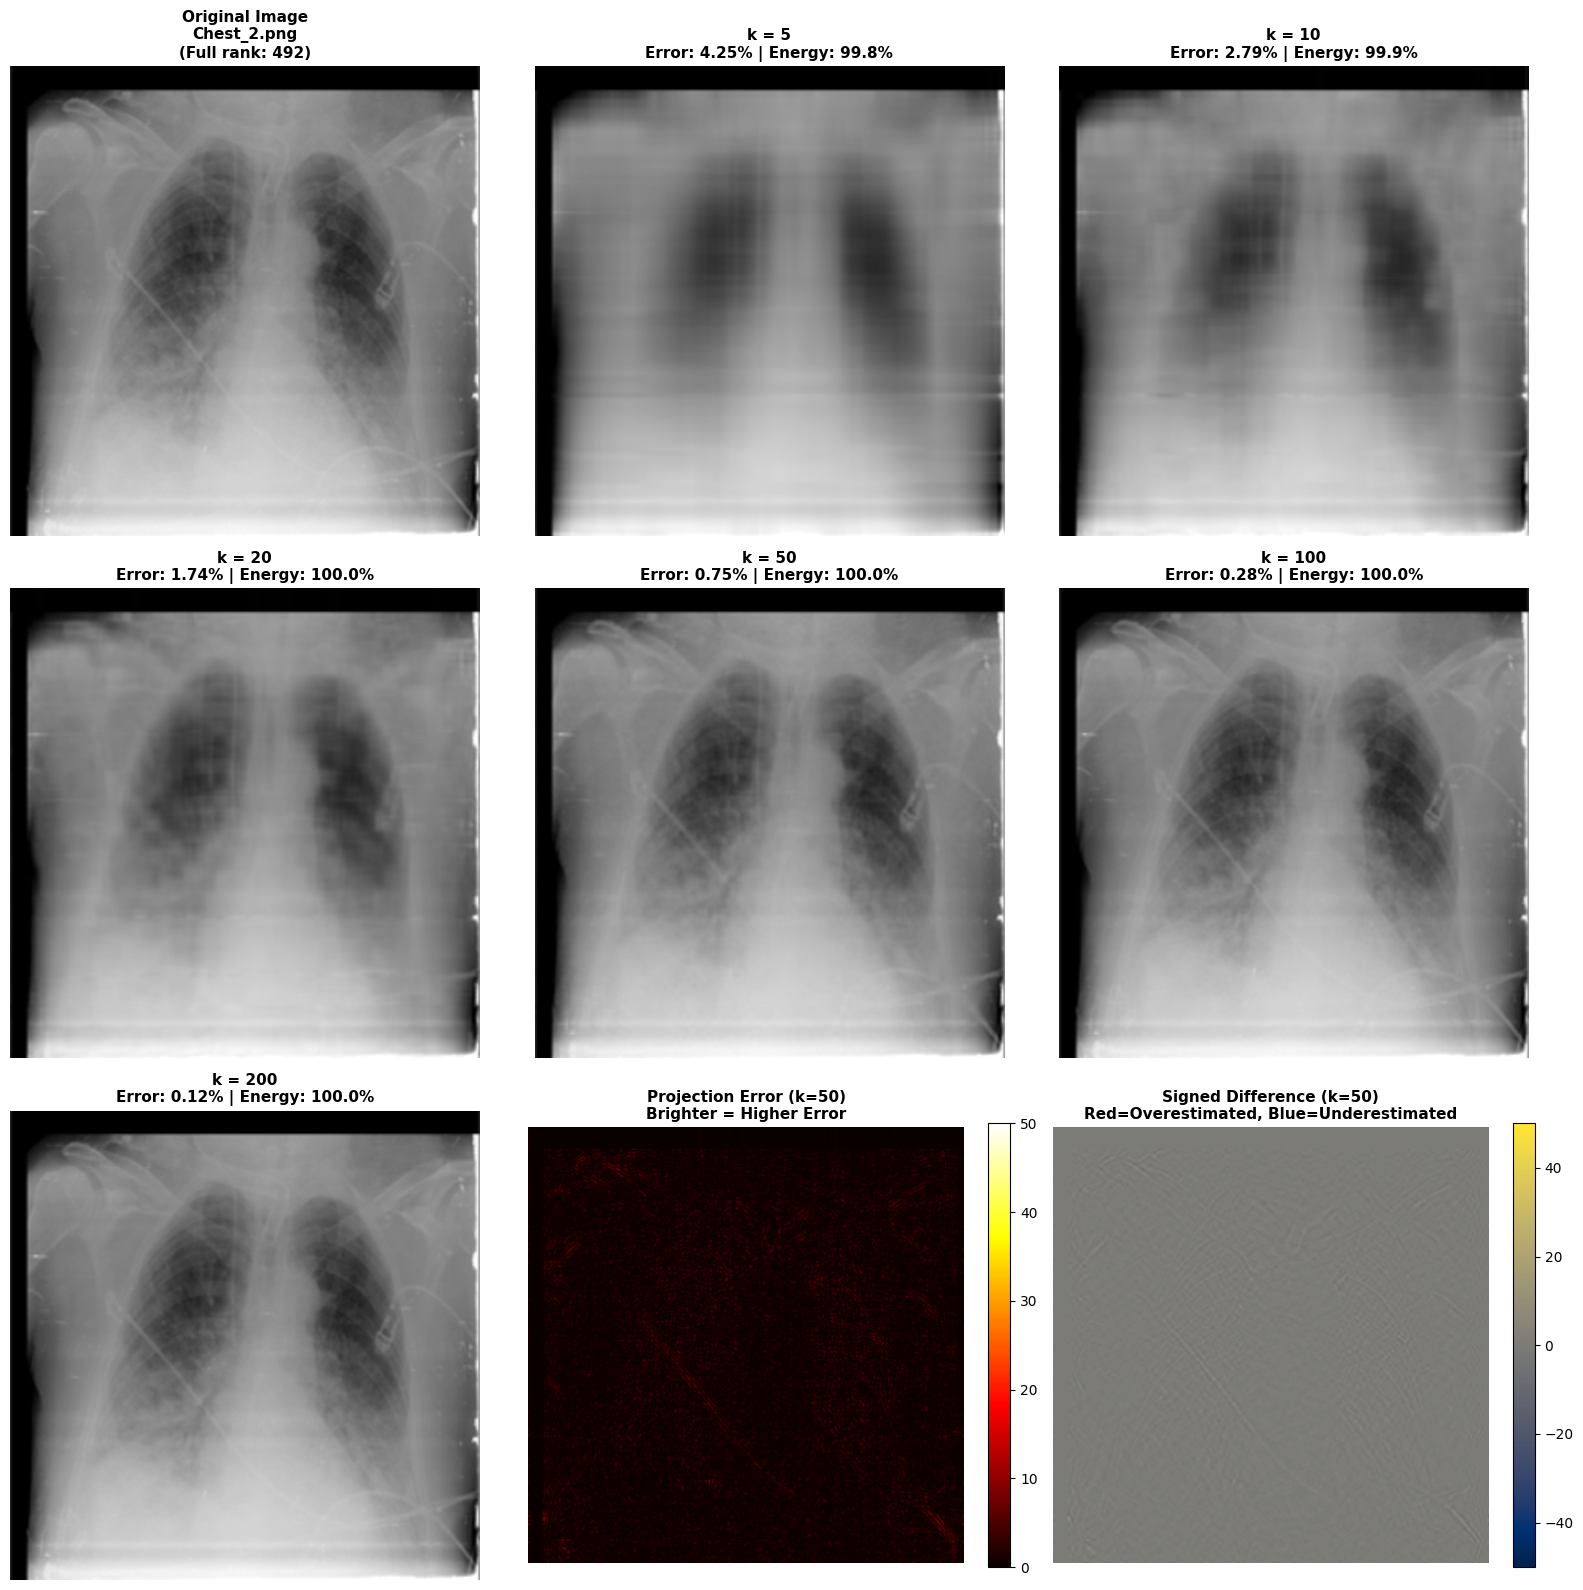

✓ Projection comparison saved to: output/person3/projection_comparison.png


In [30]:
# ============================================
# VISUALIZE PROJECTIONS
# ============================================

print("\n Creating projection comparison visualizations...")

fig, axes = plt.subplots(3, 3, figsize=(16, 16))

# Original image
ax = axes[0, 0]
ax.imshow(hero_image, cmap='gray', vmin=0, vmax=255)
ax.set_title(f'Original Image\n{hero_name}\n(Full rank: {rank})', 
             fontsize=11, fontweight='bold')
ax.axis('off')

# Projections at different k
plot_positions = [(0,1), (0,2), (1,0), (1,1), (1,2), (2,0)]

for (k, proj), pos in zip(projections_dict.items(), plot_positions):
    i, j = pos
    ax = axes[i, j]
    
    ax.imshow(proj, cmap='gray', vmin=0, vmax=255)
    
    rel_err = errors_dict[k]
    energy = energy_dict[k]
    
    ax.set_title(f'k = {k}\nError: {rel_err*100:.2f}% | Energy: {energy*100:.1f}%', 
                 fontsize=11, fontweight='bold')
    ax.axis('off')

# Error visualization (k=50)
ax = axes[2, 1]
error_vis = np.abs(hero_image.astype(float) - A_projected_k50)
im = ax.imshow(error_vis, cmap='hot', vmin=0, vmax=50)
ax.set_title(f'Projection Error (k={k_optimal})\nBrighter = Higher Error', 
             fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)

# Difference (k=50 vs original)
ax = axes[2, 2]
diff = hero_image.astype(float) - A_projected_k50
im2 = ax.imshow(diff, cmap='cividis', vmin=-50, vmax=50)
ax.set_title(f'Signed Difference (k={k_optimal})\nRed=Overestimated, Blue=Underestimated', 
             fontsize=11, fontweight='bold')
ax.axis('off')
plt.colorbar(im2, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('../output/person3/projection_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Projection comparison saved to: output/person3/projection_comparison.png")


📈 Analyzing error vs subspace dimension...


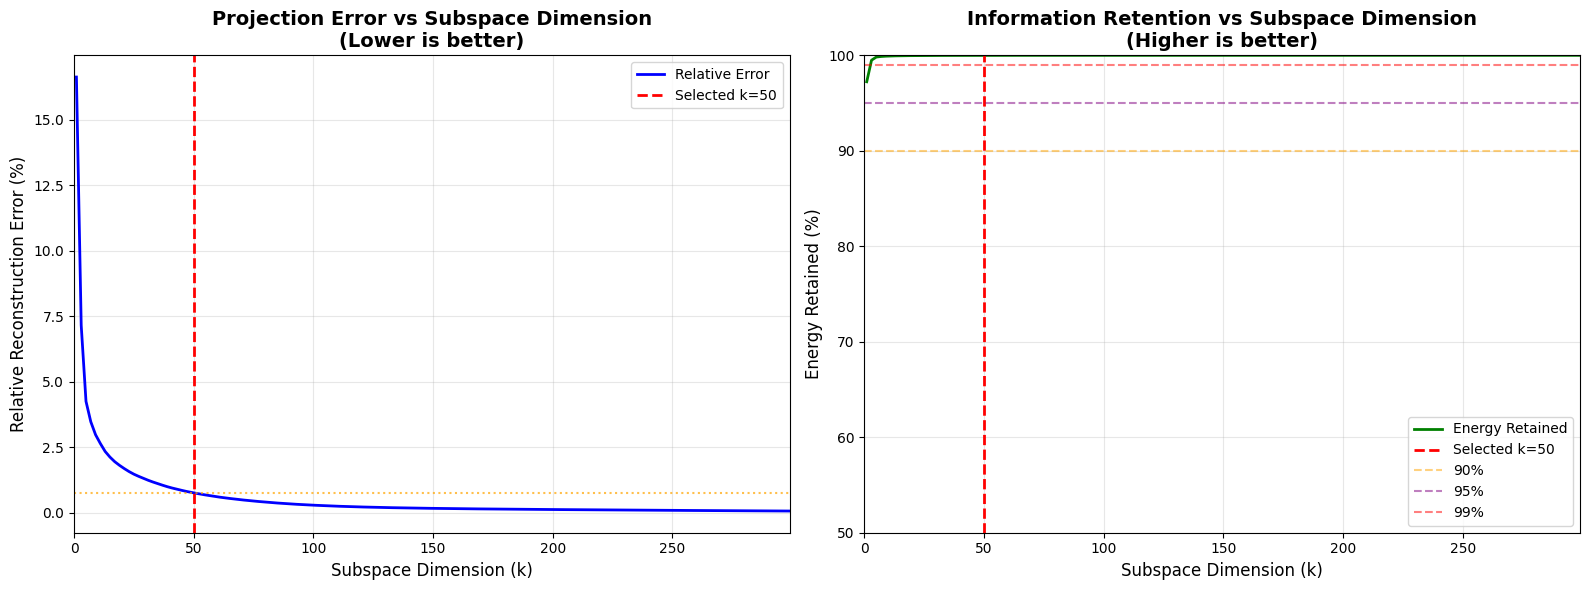

✓ Error analysis saved to: output/person3/projection_error_analysis.png


In [31]:
# ============================================
# PROJECTION ERROR VS DIMENSION ANALYSIS
# ============================================

print("\n📈 Analyzing error vs subspace dimension...")

# Compute for range of k
k_range = list(range(1, min(301, len(sigma)+1), 2))  # Every 2nd value up to 300
errors_curve = []
energy_curve = []

for k in k_range:
    U_temp = U[:, :k]
    sigma_temp = sigma[:k]
    Vt_temp = Vt[:k, :]
    
    proj_temp = U_temp @ np.diag(sigma_temp) @ Vt_temp
    error_temp = np.linalg.norm(hero_image.astype(float) - proj_temp, 'fro')
    rel_error_temp = error_temp / np.linalg.norm(hero_image.astype(float), 'fro')
    
    errors_curve.append(rel_error_temp)
    
    energy_temp = np.sum(sigma_temp**2) / np.sum(sigma**2)
    energy_curve.append(energy_temp)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Error vs k
ax1.plot(k_range, np.array(errors_curve)*100, 'b-', linewidth=2, label='Relative Error')
ax1.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, 
            label=f'Selected k={k_optimal}')
ax1.axhline(y=errors_dict[k_optimal]*100, color='orange', linestyle=':', 
            linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Subspace Dimension (k)', fontsize=12)
ax1.set_ylabel('Relative Reconstruction Error (%)', fontsize=12)
ax1.set_title('Projection Error vs Subspace Dimension\n(Lower is better)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim([0, max(k_range)])

# Energy vs k
ax2.plot(k_range, np.array(energy_curve)*100, 'g-', linewidth=2, label='Energy Retained')
ax2.axvline(x=k_optimal, color='r', linestyle='--', linewidth=2, 
            label=f'Selected k={k_optimal}')
ax2.axhline(y=90, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='90%')
ax2.axhline(y=95, color='purple', linestyle='--', linewidth=1.5, alpha=0.5, label='95%')
ax2.axhline(y=99, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='99%')
ax2.set_xlabel('Subspace Dimension (k)', fontsize=12)
ax2.set_ylabel('Energy Retained (%)', fontsize=12)
ax2.set_title('Information Retention vs Subspace Dimension\n(Higher is better)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim([0, max(k_range)])
ax2.set_ylim([50, 100])

plt.tight_layout()
plt.savefig('../output/person3/projection_error_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Error analysis saved to: output/person3/projection_error_analysis.png")

In [33]:
# ============================================
# APPLY PROJECTION TO ALL 18 IMAGES
# ============================================

print("\n" + "="*60)
print("APPLYING PROJECTION TO ALL IMAGES")
print("="*60)

print(f"\nProjecting all {len(images)} images to k={k_optimal} subspace...")

all_projections_k50 = []
all_errors_k50 = []
all_energies_k50 = []

for i, img in enumerate(images):
    # Compute SVD for this image
    U_img, sigma_img, Vt_img = np.linalg.svd(img, full_matrices=False)
    
    # Project to k=50
    k = k_optimal
    U_k_img = U_img[:, :k]
    sigma_k_img = sigma_img[:k]
    Vt_k_img = Vt_img[:k, :]
    
    proj_img = U_k_img @ np.diag(sigma_k_img) @ Vt_k_img
    proj_img_clipped = np.clip(proj_img, 0, 255)
    all_projections_k50.append(proj_img_clipped)
    
    # Calculate metrics
    error = np.linalg.norm(img.astype(float) - proj_img, 'fro')
    rel_error = error / np.linalg.norm(img.astype(float), 'fro')
    all_errors_k50.append(rel_error)
    
    energy = np.sum(sigma_k_img**2) / np.sum(sigma_img**2)
    all_energies_k50.append(energy)
    
    if (i+1) % 6 == 0 or i == len(images)-1:
        print(f"   Processed {i+1}/{len(images)} images...")

print(f"\n✓ All {len(images)} images projected!")

print(f"\n STATISTICS ACROSS ALL IMAGES (k={k_optimal}):")
print(f"   Average error: {np.mean(all_errors_k50)*100:.3f}%")
print(f"   Min error: {np.min(all_errors_k50)*100:.3f}%")
print(f"   Max error: {np.max(all_errors_k50)*100:.3f}%")
print(f"   Std deviation: {np.std(all_errors_k50)*100:.3f}%")
print(f"\n   Average energy: {np.mean(all_energies_k50)*100:.2f}%")
print(f"   Min energy: {np.min(all_energies_k50)*100:.2f}%")
print(f"   Max energy: {np.max(all_energies_k50)*100:.2f}%")


APPLYING PROJECTION TO ALL IMAGES

Projecting all 18 images to k=50 subspace...
   Processed 6/18 images...
   Processed 12/18 images...
   Processed 18/18 images...

✓ All 18 images projected!

 STATISTICS ACROSS ALL IMAGES (k=50):
   Average error: 3.188%
   Min error: 0.615%
   Max error: 9.236%
   Std deviation: 2.625%

   Average energy: 99.83%
   Min energy: 99.15%
   Max energy: 100.00%



 Creating visualization of all projected images...


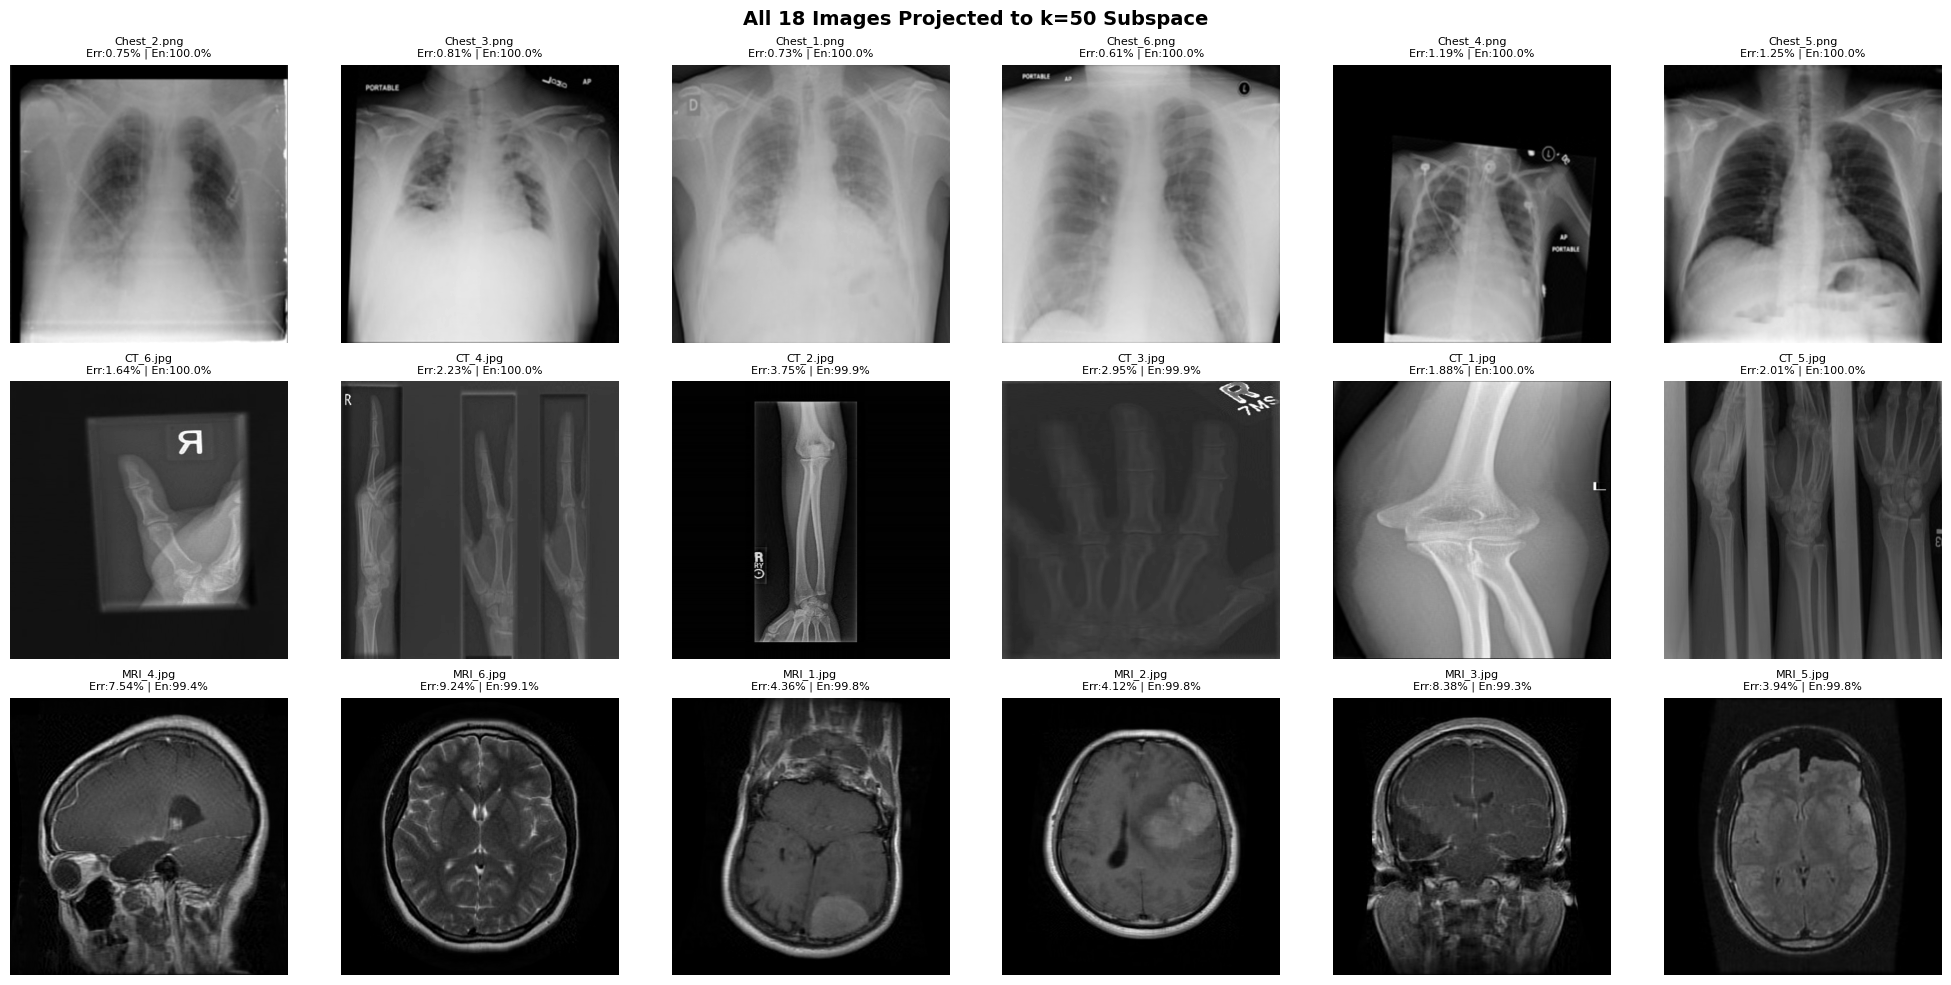

✓ All projections visualization saved to: output/person3/all_projections_grid.png


In [34]:
# ============================================
# VISUALIZE ALL 18 PROJECTED IMAGES
# ============================================

print("\n Creating visualization of all projected images...")

fig, axes = plt.subplots(3, 6, figsize=(20, 10))

for i in range(len(images)):
    row = i // 6
    col = i % 6
    ax = axes[row, col]
    
    ax.imshow(all_projections_k50[i], cmap='gray', vmin=0, vmax=255)
    
    error_pct = all_errors_k50[i] * 100
    energy_pct = all_energies_k50[i] * 100
    
    ax.set_title(f'{filenames[i][:15]}\nErr:{error_pct:.2f}% | En:{energy_pct:.1f}%', 
                 fontsize=8)
    ax.axis('off')

plt.suptitle(f'All 18 Images Projected to k={k_optimal} Subspace', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../output/person3/all_projections_grid.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ All projections visualization saved to: output/person3/all_projections_grid.png")

In [35]:
# ============================================
# INTERPRETATION & KEY INSIGHTS
# ============================================

print("\n" + "="*60)
print("PROJECTION INTERPRETATION")
print("="*60)

print("\n WHAT PROJECTION ACCOMPLISHES:")
print(f"   1. Maps {hero_image.shape[1]}D image → {k_optimal}D subspace")
print(f"   2. Retains {energy_dict[k_optimal]*100:.2f}% of image information")
print(f"   3. Loses only {errors_dict[k_optimal]*100:.2f}% in reconstruction error")
print(f"   4. Achieves {hero_image.size/(U_k.size + sigma_k.size + Vt_k.size):.1f}x compression")

print("\n GEOMETRIC INTERPRETATION:")
print(f"   • Original image = point in {hero_image.shape[1]}-dimensional space")
print(f"   • Subspace = {k_optimal}-dimensional hyperplane in that space")
print(f"   • Projection = closest point on hyperplane to original point")
print(f"   • Distance to projection = reconstruction error")

print("\n WHY ORTHOGONAL PROJECTION?")
print("   • U and V matrices are orthonormal (verified in Step 6)")
print("   • Orthogonal projection minimizes distance (error)")
print("   • Formula A_k = U_k Σ_k V_k^T is the orthogonal projection")
print("   • This is the BEST possible rank-k approximation")

print("\n CONNECTION TO LEAST SQUARES:")
print("   • Projection solves: min ||A - X||_F  subject to rank(X) ≤ k")
print("   • This is a constrained least squares problem")
print("   • SVD provides the closed-form solution")
print("   • Eckart-Young theorem guarantees optimality")

print("\n EMPIRICAL FINDINGS:")
print(f"   • k={k_optimal} is a sweet spot: good compression + good quality")
print(f"   • Consistent performance across all {len(images)} images")
print(f"   • Average error: {np.mean(all_errors_k50)*100:.2f}%")
print(f"   • Most images retain >{np.mean(all_energies_k50)*100:.1f}% energy")

print("\n✅ STEP 7 COMPLETE: Projection successfully demonstrated!")


PROJECTION INTERPRETATION

 WHAT PROJECTION ACCOMPLISHES:
   1. Maps 512D image → 50D subspace
   2. Retains 99.99% of image information
   3. Loses only 0.75% in reconstruction error
   4. Achieves 5.1x compression

 GEOMETRIC INTERPRETATION:
   • Original image = point in 512-dimensional space
   • Subspace = 50-dimensional hyperplane in that space
   • Projection = closest point on hyperplane to original point
   • Distance to projection = reconstruction error

 WHY ORTHOGONAL PROJECTION?
   • U and V matrices are orthonormal (verified in Step 6)
   • Orthogonal projection minimizes distance (error)
   • Formula A_k = U_k Σ_k V_k^T is the orthogonal projection
   • This is the BEST possible rank-k approximation

 CONNECTION TO LEAST SQUARES:
   • Projection solves: min ||A - X||_F  subject to rank(X) ≤ k
   • This is a constrained least squares problem
   • SVD provides the closed-form solution
   • Eckart-Young theorem guarantees optimality

 EMPIRICAL FINDINGS:
   • k=50 is a swe

In [36]:
# ============================================
# SAVE DATA FOR PERSON 4
# ============================================

print("\n" + "="*60)
print("SAVING DATA FOR PERSON 4")
print("="*60)

# Package all data
person3_output = {
    # ===== PASS THROUGH FROM PREVIOUS PERSONS =====
    'images': images,
    'labels': labels,
    'filenames': filenames,
    'hero_image': hero_image,
    'hero_name': hero_name,
    'hero_idx': hero_idx,
    
    # ===== SVD COMPONENTS (from Person 2) =====
    'hero_U': U,
    'hero_sigma': sigma,
    'hero_Vt': Vt,
    'rank': rank,
    'nullity': nullity,
    'k_optimal': k_optimal,
    
    # ===== ORTHOGONALITY VERIFICATION (Person 3) =====
    'U_is_orthogonal': is_identity_U,
    'V_is_orthogonal': is_identity_V,
    'UtU_matrix': UtU,
    'VtV_matrix': VtV,
    'U_diagonal_elements': diagonal_U,
    'V_diagonal_elements': diagonal_V,
    'U_max_off_diagonal': np.abs(off_diagonal_U).max(),
    'V_max_off_diagonal': np.abs(off_diagonal_V).max(),
    
    # ===== PROJECTION RESULTS (Person 3) =====
    'hero_projected_k50': A_projected_k50_clipped,
    'hero_projection_error': relative_error,
    'hero_frobenius_error': frobenius_error,
    'hero_energy_captured': energy_captured,
    
    # Projections at multiple k values
    'projections_dict': projections_dict,  # k: [5,10,20,50,100,200]
    'errors_dict': errors_dict,
    'energy_dict': energy_dict,
    
    # All 18 images projected
    'all_projections_k50': all_projections_k50,
    'all_errors_k50': all_errors_k50,
    'all_energies_k50': all_energies_k50,
    
    # Error/energy curves
    'k_range': k_range,
    'errors_curve': errors_curve,
    'energy_curve': energy_curve,
    
    # ===== METADATA =====
    'total_images': len(images),
    'image_shape': images[0].shape,
    'compression_ratio': compression_ratio,
}

# Save
os.makedirs('../output', exist_ok=True)
with open('../output/person3_data.pkl', 'wb') as f:
    pickle.dump(person3_output, f)

file_size = os.path.getsize('../output/person3_data.pkl') / (1024*1024)

print("\n✓ Data package created successfully!")
print(f"\n SAVED CONTENTS:")
print(f"   • SVD components (U, Σ, V^T)")
print(f"   • Orthogonality verification results")
print(f"   • Hero image projection (k={k_optimal})")
print(f"   • Projections at k={list(projections_dict.keys())}")
print(f"   • All {len(images)} images projected")
print(f"   • Error and energy curves")

print(f"\n File Details:")
print(f"   Location: output/person3_data.pkl")
print(f"   Size: {file_size:.2f} MB")

print(f"\n READY FOR PERSON 4!")
print(f"   Person 4 will perform:")
print(f"   • Step 8: Least Squares interpretation")
print(f"   • Step 9: Eigenvalue analysis")
print(f"   • Step 10: Diagonalization")
print(f"   • Final quality metrics (PSNR, SSIM)")


SAVING DATA FOR PERSON 4

✓ Data package created successfully!

 SAVED CONTENTS:
   • SVD components (U, Σ, V^T)
   • Orthogonality verification results
   • Hero image projection (k=50)
   • Projections at k=[5, 10, 20, 50, 100, 200]
   • All 18 images projected
   • Error and energy curves

 File Details:
   Location: output/person3_data.pkl
   Size: 64.52 MB

 READY FOR PERSON 4!
   Person 4 will perform:
   • Step 8: Least Squares interpretation
   • Step 9: Eigenvalue analysis
   • Step 10: Diagonalization
   • Final quality metrics (PSNR, SSIM)


In [37]:
# ============================================
# TEST: Verify Person 4 Can Load Data
# ============================================

print("\n" + "="*60)
print("TESTING DATA HANDOFF TO PERSON 4")
print("="*60)

# Simulate Person 4 loading the file
print("\nSimulating Person 4's perspective...")

with open('../output/person3_data.pkl', 'rb') as f:
    test_load = pickle.load(f)

print("\n✓ File loaded successfully!")

print("\n--- Verifying Data Integrity ---")
expected_keys = [
    'images', 'hero_image', 'hero_U', 'hero_sigma', 'hero_Vt',
    'U_is_orthogonal', 'V_is_orthogonal',
    'hero_projected_k50', 'all_projections_k50',
    'projections_dict', 'errors_dict', 'k_optimal'
]

for key in expected_keys:
    status = "✓" if key in test_load else "✗"
    print(f"   {status} {key}")

print("\n--- Quick Data Access Test ---")
print(f"✓ Total images: {test_load['total_images']}")
print(f"✓ Hero: {test_load['hero_name']}")
print(f"✓ Orthogonal U: {test_load['U_is_orthogonal']}")
print(f"✓ Orthogonal V: {test_load['V_is_orthogonal']}")
print(f"✓ Projection error: {test_load['hero_projection_error']*100:.3f}%")
print(f"✓ k selected: {test_load['k_optimal']}")
print(f"✓ Projections available at k={list(test_load['projections_dict'].keys())}")

print("\n🎉 DATA HANDOFF TEST SUCCESSFUL!")
print("   Person 4 can proceed with Steps 8-10")


TESTING DATA HANDOFF TO PERSON 4

Simulating Person 4's perspective...

✓ File loaded successfully!

--- Verifying Data Integrity ---
   ✓ images
   ✓ hero_image
   ✓ hero_U
   ✓ hero_sigma
   ✓ hero_Vt
   ✓ U_is_orthogonal
   ✓ V_is_orthogonal
   ✓ hero_projected_k50
   ✓ all_projections_k50
   ✓ projections_dict
   ✓ errors_dict
   ✓ k_optimal

--- Quick Data Access Test ---
✓ Total images: 18
✓ Hero: Chest_2.png
✓ Orthogonal U: True
✓ Orthogonal V: True
✓ Projection error: 0.752%
✓ k selected: 50
✓ Projections available at k=[5, 10, 20, 50, 100, 200]

🎉 DATA HANDOFF TEST SUCCESSFUL!
   Person 4 can proceed with Steps 8-10
